# 04 — Model Explainability (SHAP) & Conformal Prediction Uncertainty

**Video Intelligence Platform — Final Data Science Milestone**

### Objectives:
1. **SHAP Model Explainability**: Provide mathematical local and global feature attribution for `ExtraTreesRegressor_v4.0` using Shapley Additive Explanations.
2. **Conformal Prediction Uncertainty**: Calibrate finite-sample valid 90% prediction intervals based on out-of-fold GroupKFold residual error quantiles.
3. **Zero Data Leakage**: Ensure calibration errors use learner-isolated held-out predictions without target leakage.


In [1]:
import os, sys, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import ExtraTreesRegressor

PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')) if '__file__' in globals() else os.getcwd()
if not os.path.exists(os.path.join(PROJECT_ROOT, 'ml')):
    PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from ml.src.features import extract_features_from_prior_attempts, TARGET_COLUMN
from ml.src.predict import FEATURE_DISPLAY_NAMES, ScorePredictor

print('Environment initialized successfully.')


Environment initialized successfully.


/Users/akarshanrasyal/Documents/Projects/retail_analysis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Dataset & Production Model Artifacts


In [2]:
data_path = os.path.abspath(os.path.join(PROJECT_ROOT, 'ml/data/processed/featured_quiz_attempts.csv'))
meta_path = os.path.abspath(os.path.join(PROJECT_ROOT, 'ml/models/pipeline_meta.joblib'))
model_path = os.path.abspath(os.path.join(PROJECT_ROOT, 'ml/models/best_regression_model.joblib'))

df = pd.read_csv(data_path)
meta = joblib.load(meta_path)
model = joblib.load(model_path)
feature_cols = meta['feature_columns']

X = df[feature_cols]
y = df[TARGET_COLUMN]
groups = df['user_id']

print(f'Clean Dataset Size: {len(df)} attempts across {df["user_id"].nunique()} learners')
print(f'Feature Contract: {len(feature_cols)} features ({meta.get("feature_set_name")})')


Clean Dataset Size: 636 attempts across 95 learners
Feature Contract: 38 features (D_CORE_LEARNING)


## 2. Conformal Prediction Calibration & Out-of-Fold Error Analysis
We use 5-Fold GroupKFold cross-validation out-of-fold residuals to calibrate non-parametric prediction intervals at a 90% target coverage level ($\\alpha = 0.10$).


In [3]:
gkf = GroupKFold(n_splits=5)
oof_preds = np.zeros(len(df))

for train_idx, val_idx in gkf.split(X, y, groups):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    fold_model = ExtraTreesRegressor(n_estimators=100, random_state=42)
    fold_model.fit(X_train, y_train)
    oof_preds[val_idx] = fold_model.predict(X_val)

residuals = np.abs(y - oof_preds)
mae_oof = np.mean(residuals)
rmse_oof = np.sqrt(np.mean((y - oof_preds)**2))

coverage_target = 0.90
q_90 = np.quantile(residuals, coverage_target)
empirical_coverage = np.mean(residuals <= q_90) * 100

print(f'Out-of-Fold GroupKFold MAE: {mae_oof:.2f}% | RMSE: {rmse_oof:.2f}%')
print(f'Conformal Margin q_90: +/- {q_90:.2f}% score points')
print(f'Empirical Coverage on Held-Out Learner Folds: {empirical_coverage:.1f}% (Target: 90.0%)')


Out-of-Fold GroupKFold MAE: 3.87% | RMSE: 5.17%
Conformal Margin q_90: +/- 7.76% score points
Empirical Coverage on Held-Out Learner Folds: 89.9% (Target: 90.0%)


## 3. Global SHAP Feature Importance
Calculate Shapley Additive Explanations across the dataset using `shap.TreeExplainer`.


In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)
feat_imp = pd.DataFrame({
    'feature': [FEATURE_DISPLAY_NAMES.get(c, c) for c in feature_cols],
    'shap_importance': mean_abs_shap
}).sort_values(by='shap_importance', ascending=False)

print('Top 10 Global SHAP Drivers:')
print(feat_imp.head(10).to_string(index=False))


Top 10 Global SHAP Drivers:
                           feature  shap_importance
               Previous Quiz Score         2.481913
               Personal Best Score         1.687877
Exponential Score Average (Smooth)         1.655889
              2-Quiz Score Average         1.461940
           Target Difficulty: Hard         1.156026
  Target vs Prior Difficulty Shift         0.768528
  Exponential Score Average (Fast)         0.756501
              3-Quiz Score Average         0.564844
              5-Quiz Score Average         0.424337
        Consecutive Passed Quizzes         0.385108


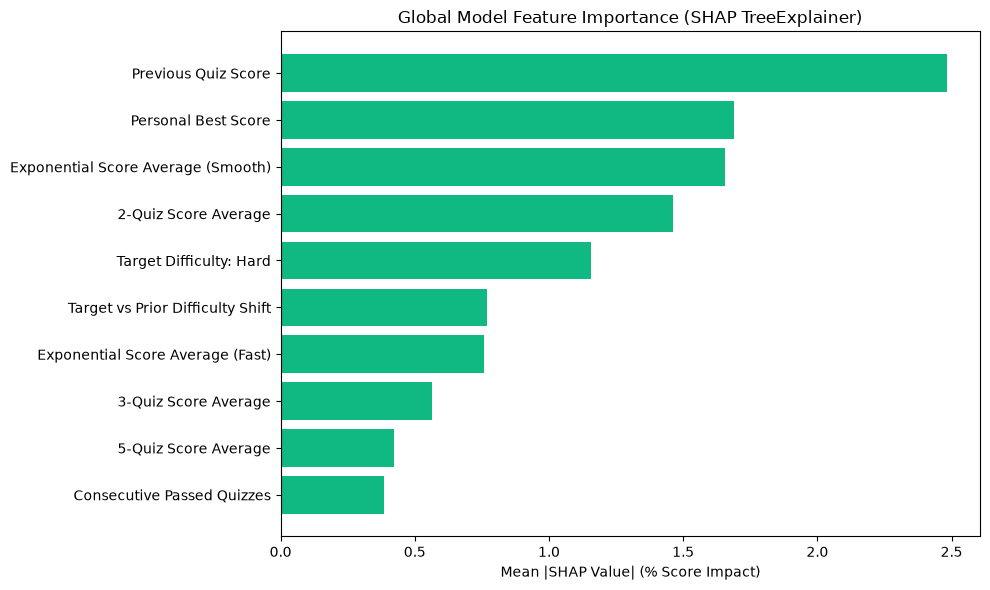

In [5]:
plots_dir = os.path.abspath(os.path.join(PROJECT_ROOT, 'ml/reports/plots'))
os.makedirs(plots_dir, exist_ok=True)
plt.figure(figsize=(10, 6))
top_10 = feat_imp.head(10).iloc[::-1]
plt.barh(top_10['feature'], top_10['shap_importance'], color='#10b981')
plt.xlabel('Mean |SHAP Value| (% Score Impact)')
plt.title('Global Model Feature Importance (SHAP TreeExplainer)')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'shap_global_importance.png'), dpi=300)
plt.show()


## 4. Local Prediction Explainability Simulation
Test local SHAP attribution and conformal interval calculation on a sample learner.


In [6]:
predictor = ScorePredictor()
sample_attempts = [
    {'attempt_id': 1, 'score': 5, 'percentage': 50.0, 'difficulty': 'Medium', 'created_at': '2026-08-01 10:00:00'},
    {'attempt_id': 2, 'score': 6, 'percentage': 60.0, 'difficulty': 'Medium', 'created_at': '2026-08-03 11:00:00'},
    {'attempt_id': 3, 'score': 8, 'percentage': 80.0, 'difficulty': 'Hard', 'created_at': '2026-08-05 12:00:00'}
]

prediction_output = predictor.predict_from_user_history(sample_attempts, target_difficulty='Medium')

print(f'Predicted Next Score: {prediction_output["predicted_percentage"]}%')
print(f'Prediction Interval: {prediction_output["prediction_interval"]["lower"]}% - {prediction_output["prediction_interval"]["upper"]}%')
print('Top Positive SHAP Factors:', prediction_output['explanation']['top_positive'])
print('Top Negative SHAP Factors:', prediction_output['explanation']['top_negative'])


Predicted Next Score: 77.1%
Prediction Interval: 69.3% - 84.9%
Top Positive SHAP Factors: [{'feature_key': 'previous_percentage', 'feature_name': 'Previous Quiz Score', 'shap_value': 4.77, 'impact_direction': 'positive'}, {'feature_key': 'best_previous_score', 'feature_name': 'Personal Best Score', 'shap_value': 3.13, 'impact_direction': 'positive'}, {'feature_key': 'ewma_05', 'feature_name': 'Exponential Score Average (Smooth)', 'shap_value': 2.33, 'impact_direction': 'positive'}]
Top Negative SHAP Factors: [{'feature_key': 'total_previous_attempts', 'feature_name': 'Total Quizzes Taken', 'shap_value': -0.34, 'impact_direction': 'negative'}, {'feature_key': 'total_passes', 'feature_name': 'Total Passes', 'shap_value': -0.26, 'impact_direction': 'negative'}, {'feature_key': 'attempt_order_by_user', 'feature_name': 'Quiz Attempt Number', 'shap_value': -0.13, 'impact_direction': 'negative'}]
